In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch

from brain_image.model.comm.comm import CoMM
from brain_image.model.comm.encoders import AlexNetEncoder
from brain_image.model.comm.input_adapters import FeaturesInputAdapter, PatchedInputAdapter
from brain_image.model.comm.mmfusion import MMFusion
from brain_image.model.eeg_encoder.atms import AtmsEEGEncoder, AtmsEEGEncoderConfig
from brain_image.model.img_encoder import CLIPImageEncoder

from torch.utils.data import DataLoader
from pathlib import Path

from brain_image.data.things_eeg2_dataset import ThingsEEG2Dataset, ThingsEEG2DatasetConfig


/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [4]:
things_path = Path("data/things-eeg2")
dataset_config = ThingsEEG2DatasetConfig(subs=[1], num_workers=0)
dataset = ThingsEEG2Dataset(
    dataset_config, 
    split="test", 
)
loader = DataLoader(dataset, batch_size=4, num_workers=0)

In [5]:
from brain_image.data.data import batch_load_images, load_image_from_path


ex_batch = next(iter(loader))
img = batch_load_images(ex_batch["img_path"])
eeg = ex_batch["eeg_data"]

img = img.to(device="cuda", dtype=float)
eeg = eeg.to(device="cuda", dtype=float)

...;

In [6]:
comm = CoMM(
    encoder=MMFusion(
        encoders=[ # Symmetric visual encoders
            #AlexNetEncoder(latent_dim=512, global_pool=""), 
            CLIPImageEncoder(), # 1024
            AtmsEEGEncoder(AtmsEEGEncoderConfig(d_channels=63, d_output=768))
        ], 
        input_adapters=[ # Pach adapters for multimodal fusion
            FeaturesInputAdapter(768, 512),
            #PatchedInputAdapter(num_channels=256, stride_level=1, patch_size_full=1, dim_tokens=512, image_size=6),
            #PatchedInputAdapter(num_channels=256, stride_level=1, patch_size_full=1, dim_tokens=512, image_size=6)
            FeaturesInputAdapter(768, 512)
        ],
        embed_dim=512
    ),
    projection=CoMM._build_mlp(512, 512, 256),
    optim_kwargs=dict(lr=3e-4, weight_decay=1e-4),
    loss_kwargs=dict(temperature=0.1)
)
comm.to(device="cuda", dtype=float)

CoMM(
  (encoder): MMFusion(
    (input_adapters): ModuleList(
      (0-1): 2 x FeaturesInputAdapter()
    )
    (encoders): ModuleList(
      (0): CLIPImageEncoder(
        (model): CLIPVisionModelWithProjection(
          (vision_model): CLIPVisionTransformer(
            (embeddings): CLIPVisionEmbeddings(
              (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
              (position_embedding): Embedding(257, 1024)
            )
            (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (encoder): CLIPEncoder(
              (layers): ModuleList(
                (0-23): 24 x CLIPEncoderLayer(
                  (self_attn): CLIPAttention(
                    (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                    (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                    (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
               

In [7]:
from brain_image.model.img_encoder import CLIPImageEncoder


clip_enc = comm.encoder.encoders[0]  

i1 = clip_enc.preprocess(img)
c = clip_enc.model(i1)

c.last_hidden_state.shape

torch.Size([4, 257, 1024])

In [8]:
#comm.forward([imgs / 255., eeg], [imgs / 255., eeg])

with torch.no_grad():
    out = comm.forward([img, eeg], [img, eeg])

out.keys()

dict_keys(['aug1_embed', 'aug2_embed', 'prototype'])

In [9]:
from brain_image.model.comm.comm_loss import CoMMLoss


comm_loss = CoMMLoss()
comm_loss.to(device="cuda", dtype=float)

comm_loss(out)

{'loss': tensor(0.5084, device='cuda:0', dtype=torch.float64),
 'ssl_acc': tensor(91.6667, device='cuda:0'),
 'ssl_acc_0': tensor(100., device='cuda:0'),
 'ssl_acc_1': tensor(75., device='cuda:0'),
 'ssl_acc_2': tensor(100., device='cuda:0'),
 'ssl_loss_0': tensor(0.2177, device='cuda:0', dtype=torch.float64),
 'ssl_loss_1': tensor(1.0070, device='cuda:0', dtype=torch.float64),
 'ssl_loss_2': tensor(0.3004, device='cuda:0', dtype=torch.float64)}

In [10]:
from torch import Tensor
import torch
from torch import nn
from torchvision.transforms import v2 as tv2


class EEGAugmenter(nn.Module):
    # From M. Mohsenvand et al. "Contrastive Representation Learning for Electroencephalogram Classification"
    # Augmentations:
    # - Amplitude scale
    # - Time shift
    # - DC shift
    # - Zero masking
    # - Gaussian noise
    # - Band-Stop filtering 


    def __init__(
        self,
        amplitude_scale_min: float = 0.5,
        amplitude_scale_max: float = 2,
        amplitude_scale_prob: float = 0.2,

        time_shift_scale: float = 0.2,
        time_shift_prob: float = 0.2,

        dc_shift_max: float = 5,
        dc_shift_prob: float = 2,
        
        zero_masking_prob: float = 0.2,
        zero_masking_length: float = 0.2,

        gaussian_noise_std: float = 0.2,
        gaussian_noise_prob: float = 0.2,

        bandstop_filter_min: float = 2.8,
        bandstop_filter_max: float = 82.5,
        bandstop_filter_prob: float = 0.2,
    ):
        super().__init__()
        
        self.amplitude_scale_min = amplitude_scale_min


    def forward(self, eeg: Tensor) -> Tensor:
        assert eeg.ndim == 3

        eeg = eeg.clone()  # <num_samples, num_channels, timelength>
        num_samples, num_channels, timelength = eeg.size()

        # Mask channels
        if self.drop_channels > 0:
            mask = (
                torch.rand(num_samples, num_channels, 1, device=eeg.device)
                > self.drop_channels
            )
            eeg = eeg * mask

        # Mask time points
        if self.drop_time_points > 0:
            mask = (
                torch.rand(num_samples, 1, timelength, device=eeg.device)
                > self.drop_time_points
            )
            eeg = eeg * mask

        # Shift time points
        if self.max_timeshift > 0:
            max_shift = int(self.max_timeshift * timelength)
            shifts = torch.randint(
                -max_shift, max_shift, (num_samples,), device=eeg.device
            )
            for i, s in enumerate(shifts):
                if s > 0:
                    # Left shift
                    eeg[i, :, :-s] = eeg[i, :, s:]
                    eeg[i, :, -s:] = 0      # TODO: Make random or last value or zero
                elif s < 0:
                    # Right shift
                    eeg[i, :, -s:] = eeg[i, :, :s]
                    eeg[i, :, :-s] = 0

        # Add Gaussian noise
        if self.noise_std > 0:
            noise = torch.randn_like(eeg) * self.noise_std
            eeg = eeg + noise

        return eeg


class ImageAugmenter(nn.Module):
    # Augmentation: Image -> Random flip, Random color jitter, Gaussian blur

    def __init__(
        self,
        hflip_prob: float = 0.5,
        vflip_prob: float = 0.25,
        color_jitter_brightness: float = 0.1,
        color_jitter_contrast: float = 0.1,
        color_jitter_saturation: float = 0.1,
        color_jitter_hue: float = 0.1,
        color_jitter_prob: float = 0.5,
        mask_prob: float = 0.1,
        mask_patch_size: int = 10,
        blur: float = 0.1,
        blur_kernel_size: int = 5,
    ):
        super().__init__()
        self.hflip_prob = hflip_prob
        self.vflip_prob = vflip_prob
        self.mask_prob = mask_prob
        self.mask_patch_size = mask_patch_size
        self.blur = blur
        self.color_jitter_prob = color_jitter_prob

        self.color_jitter = tv2.ColorJitter(
            brightness=color_jitter_brightness,
            contrast=color_jitter_contrast,
            saturation=color_jitter_saturation,
            hue=color_jitter_hue,
        )
        
        self.vflip = tv2.RandomVerticalFlip(vflip_prob)
        self.hflip = tv2.RandomHorizontalFlip(hflip_prob)
        self.gaussian_blur = tv2.GaussianBlur(kernel_size=blur_kernel_size, sigma=(0.1, 2.0))

    def forward(self, img: Tensor) -> Tensor:
        assert img.ndim == 4
        img = img.clone()  # <num_samples, 3, H, W>

        if self.hflip_prob > 0:
            img = self.hflip(img)
        
        if self.vflip_prob > 0:
            img = self.vflip(img)

        if self.color_jitter_prob > 0:
            img = self.color_jitter(img)

        if self.blur:
            img = self.gaussian_blur(img)

        return img


In [11]:
torch.roll
eeg.roll(shifts=1)

tensor([[[-2.1110e-01,  1.1277e-01,  3.1687e-02,  ...,  3.4775e-01,
           3.5543e-01,  3.1859e-01],
         [ 2.8966e-01,  7.3489e-02,  6.5811e-02,  ...,  4.8283e-02,
           1.2747e-01,  2.3691e-01],
         [ 2.3778e-01,  1.3591e-02,  1.1802e-01,  ...,  1.8739e-01,
           5.3354e-02,  7.7487e-02],
         ...,
         [-3.9753e-01,  1.4103e-01, -6.5679e-02,  ..., -2.5205e-01,
          -2.3990e-01, -2.3187e-01],
         [-2.3913e-01,  1.0925e-01,  1.1318e-01,  ...,  3.2762e-02,
          -1.0910e-02, -3.3489e-02],
         [-4.4363e-02, -1.2792e-01, -3.3896e-02,  ..., -8.6883e-02,
          -9.2626e-02, -1.3644e-01]],

        [[-9.6718e-02, -2.0228e-02, -3.5413e-02,  ...,  3.4003e-01,
           2.1644e-01,  2.1082e-01],
         [ 2.7549e-01, -6.3070e-02, -3.1508e-03,  ...,  1.2710e-01,
           1.2749e-01,  1.2393e-01],
         [ 1.5714e-01, -1.4539e-02,  8.1131e-02,  ..., -3.5563e-01,
          -3.0759e-01, -2.7506e-01],
         ...,
         [-2.4892e-01,  1

In [13]:
eeg_augmenter = EEGAugmenter(drop_channels=0, drop_time_points=0, noise_std=0.0, max_timeshift=0.1)
image_augmenter = ImageAugmenter()

eeg_aug1 = eeg_augmenter(eeg)
eeg_aug2 = eeg_augmenter(eeg)

img_aug1 = image_augmenter(img)
img_aug2 = image_augmenter(img)

TypeError: EEGAugmenter.__init__() got an unexpected keyword argument 'drop_channels'

In [14]:
I = torch.arange(eeg.size(2)).repeat(3, 1)
I.shape

torch.Size([3, 250])

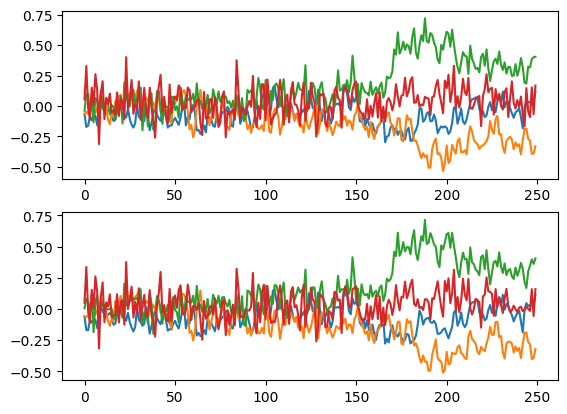

In [55]:
import matplotlib.pyplot as plt
import numpy as np

from brain_image.augment import AugmentAmplitudeScale, AugmentAmplitudeShift, AugmentBandStopFilter, AugmentGaussianNoise, AugmentTimeShift, AugmentZeroMasking, EEGAugmentationPipeline 

eeg_aug = eeg
#eeg_aug = AugmentAmplitudeScale(prob=1)(eeg_aug)
#eeg_aug = AugmentTimeShift(prob=1)(eeg_aug)
#eeg_aug = AugmentAmplitudeShift(prob=1)(eeg_aug)
#eeg_aug = AugmentZeroMasking(prob=1)(eeg_aug)
#eeg_aug = AugmentGaussianNoise(prob=1)(eeg_aug)
#eeg_aug = AugmentBandStopFilter(prob=1, width_hz=5)(eeg_aug)
eeg_aug = EEGAugmentationPipeline()(eeg_aug)

C = 4
nC = 4
S = 0
I = torch.arange(eeg.size(2)).repeat(nC, 1)


plt.subplot(2, 1, 1)
plt.plot(I.T, eeg[S, C:C+nC].T.detach().cpu().numpy())
plt.subplot(2, 1, 2)
plt.plot(I.T,  eeg_aug[S, C:C+nC].T.detach().cpu().numpy())

...;

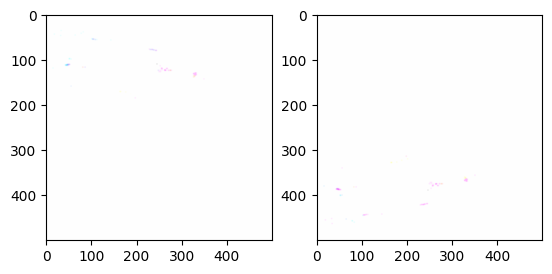

In [72]:
import matplotlib.pyplot as plt 
plt.subplot(1, 2, 1)
plt.imshow(img_aug1[0].permute(1, 2, 0).detach().cpu().numpy())
plt.subplot(1, 2, 2)
plt.imshow(img_aug2[0].permute(1, 2, 0).detach().cpu().numpy())
